# Cryptocurrency Price Prediction - Model Comparison

This notebook compares baseline ML/DL models for crypto price forecasting.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
from src.load_data import load_crypto_data
from src.models.linear_regression import train_linear_regression, evaluate_linear_regression
from src.models.random_forest import train_random_forest, evaluate_random_forest
from src.models.xgboost import train_xgboost, evaluate_xgboost
from src.models.svr import train_svr, evaluate_svr
from src.models.lstm import train_lstm, evaluate_lstm

In [2]:
# Load and preprocess data
try:
    df, _, _ = load_crypto_data('BTC-USD')
except FileNotFoundError as e:
    print(e)
    print('Running fetch_historical.py to download missing files...')
    import subprocess
    subprocess.run(['python', '../src/fetch_historical.py'], check=False)
    df, _, _ = load_crypto_data('BTC-USD')

df = df.dropna()  # Basic clean

# Split
train_size = int(0.7 * len(df))
X = df[['Open', 'High', 'Low', 'Volume']].values  # Only basic features
y = df['Close'].values
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]



=== BTC-USD Dataset ===
First 5 rows:
        Date        Open        High         Low       Close    Volume
0 2015-01-01  320.434998  320.434998  314.002991  314.248993   8036550
1 2015-01-02  314.079010  315.838989  313.565002  315.032013   7860650
2 2015-01-03  314.846008  315.149994  281.082001  281.082001  33054400
3 2015-01-04  281.145996  287.230011  257.612000  264.195007  55629100
4 2015-01-05  265.084015  278.341003  265.084015  274.473999  43962800

Last 5 rows:
           Date          Open          High           Low         Close  \
4104 2026-03-28  66338.500000  67232.859375  65906.742188  66319.695312   
4105 2026-03-29  66319.695312  67052.953125  64971.707031  65954.921875   
4106 2026-03-30  65958.351562  68087.289062  65759.804688  66691.445312   
4107 2026-03-31  66694.585938  68495.273438  65950.437500  68233.312500   
4108 2026-04-02  68095.265625  68485.039062  68095.265625  68311.781250   

           Volume  
4104  20924883455  
4105  21645889785  
4106  3769

In [3]:
# Train and evaluate
models = {
    'Linear Regression': (train_linear_regression, evaluate_linear_regression),
    'Random Forest': (train_random_forest, evaluate_random_forest),
    'XGBoost': (train_xgboost, evaluate_xgboost),
    'SVR': (train_svr, evaluate_svr),
    'LSTM': (train_lstm, evaluate_lstm),
}

results = {}
for name, (train_func, eval_func) in models.items():
    try:
        if name == 'LSTM':
            # LSTM is sequence-based and expects only a single sequential target variable
            train_func(y_train, y_train, seq_length=30)
            results[name] = eval_func(y_test, y_test, seq_length=30)
        else:
            train_func(X_train, y_train)
            results[name] = eval_func(X_test, y_test)
    except Exception as e:
        print(f"Skipping {name} due to error: {e}")

results_df = pd.DataFrame(results).T
print(results_df)



                             MAE           RMSE        MAPE         R2  \
Linear Regression     456.241656     687.587848    0.688838   0.999529   
Random Forest       13020.299308   21694.318277   13.213736   0.531034   
XGBoost             14214.002321   22981.248978   15.083648   0.473745   
SVR                 56640.397134   64964.048771   82.971648  -3.205286   
LSTM               187473.804239  190044.802231  421.430696 -36.211047   

                   Directional_Accuracy  
Linear Regression             80.275974  
Random Forest                 46.590909  
XGBoost                       54.139610  
SVR                           46.834416  
LSTM                           0.000000  


## Model Selection

Based on RMSE and R², Linear Regression performs best with lowest RMSE (687.59) and highest R² (0.9995). It is selected for its accuracy, simplicity, and suitability for deployment in a live dashboard.

### Results Summary:
- **Linear Regression**: RMSE 687.59, R² 0.9995 ✓ **BEST**
- Random Forest: RMSE 21,694.32, R² 0.5310
- XGBoost: RMSE 22,981.25, R² 0.4737
- SVR: RMSE 64,964.05, R² -3.2053
- LSTM: RMSE 94,057.52, R² -8.1148

In [10]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

In [ ]:
data_folder = "src/historical_data"

files = [
    "BTC-USD_historical.csv",
    "ETH-USD_historical.csv",
    "ADA-USD_historical.csv",
    "SOL-USD_historical.csv"
]

file_paths = [os.path.join(data_folder, f) for f in files]
file_paths

['src/historical_data\\BTC-USD_historical.csv',
 'src/historical_data\\ETH-USD_historical.csv',
 'src/historical_data\\ADA-USD_historical.csv',
 'src/historical_data\\SOL-USD_historical.csv']

In [ ]:
import os
print(os.getcwd())

c:\Users\anjal\Cryptocurrency-price-prediction\notebooks


In [ ]:
import os

data_folder = "historical_data"   # change this if needed

files = [
    "BTC-USD_historical.csv",
    "ETH-USD_historical.csv",
    "ADA-USD_historical.csv",
    "SOL-USD_historical.csv"
]

file_paths = [os.path.join(data_folder, f) for f in files]

for path in file_paths:
    print(path, "Exists:", os.path.exists(path))

historical_data\BTC-USD_historical.csv Exists: False
historical_data\ETH-USD_historical.csv Exists: False
historical_data\ADA-USD_historical.csv Exists: False
historical_data\SOL-USD_historical.csv Exists: False


In [5]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

./best_model_per_coin.csv
./all_model_comparison_results.csv
./overall_model_summary.csv


In [6]:
import os
print("Current working directory:")
print(os.getcwd())
print("\nItems in current folder:")
print(os.listdir())

Current working directory:
/Users/shyamshrestha/crypto-price-prediction/notebooks

Items in current folder:
['model_comparison 2.ipynb', 'best_model_per_coin.csv', 'all_model_comparison_results.csv', 'model_comparison_executed.ipynb', 'crypto_eda.ipynb', 'model_comparison_executed.ipynb.bak', 'overall_model_summary.csv', '.ipynb_checkpoints', 'model_comparison.ipynb', 'crypto_eda.html']


In [7]:
data_folder = "../src/historical_data"

files = [
    "BTC-USD_historical.csv",
    "ETH-USD_historical.csv",
    "ADA-USD_historical.csv",
    "SOL-USD_historical.csv"
]

file_paths = [os.path.join(data_folder, f) for f in files]
file_paths

['../src/historical_data/BTC-USD_historical.csv',
 '../src/historical_data/ETH-USD_historical.csv',
 '../src/historical_data/ADA-USD_historical.csv',
 '../src/historical_data/SOL-USD_historical.csv']

In [8]:
import os
import pandas as pd

data_folder = "../src/historical_data"

files = [
    "BTC-USD_historical.csv",
    "ETH-USD_historical.csv",
    "ADA-USD_historical.csv",
    "SOL-USD_historical.csv"
]

file_paths = [os.path.join(data_folder, f) for f in files]

for path in file_paths:
    print(path, "Exists:", os.path.exists(path))

sample_df = pd.read_csv(file_paths[0])
print("\nFirst 5 rows:")
print(sample_df.head())

print("\nColumns:")
print(sample_df.columns.tolist())

../src/historical_data/BTC-USD_historical.csv Exists: True
../src/historical_data/ETH-USD_historical.csv Exists: True
../src/historical_data/ADA-USD_historical.csv Exists: True
../src/historical_data/SOL-USD_historical.csv Exists: True

First 5 rows:
        Price                Open                High                 Low  \
0      Ticker             BTC-USD             BTC-USD             BTC-USD   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-01  320.43499755859375  320.43499755859375  314.00299072265625   
3  2015-01-02   314.0790100097656   315.8389892578125  313.56500244140625   
4  2015-01-03  314.84600830078125   315.1499938964844   281.0820007324219   

               Close    Volume  
0            BTC-USD   BTC-USD  
1                NaN       NaN  
2  314.2489929199219   8036550  
3  315.0320129394531   7860650  
4  281.0820007324219  33054400  

Columns:
['Price', 'Open', 'High', 'Low', 'Close', 'Volume']


In [22]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, short_window=12, long_window=26, signal_window=9):
    ema_short = series.ewm(span=short_window, adjust=False).mean()
    ema_long = series.ewm(span=long_window, adjust=False).mean()
    macd = ema_short - ema_long
    macd_signal = macd.ewm(span=signal_window, adjust=False).mean()
    return macd, macd_signal

def create_features(df):
    df = df.copy()

    df["lag_1"] = df["Close"].shift(1)
    df["lag_2"] = df["Close"].shift(2)
    df["lag_3"] = df["Close"].shift(3)

    df["ma_7"] = df["Close"].rolling(7).mean()
    df["ma_14"] = df["Close"].rolling(14).mean()
    df["ma_30"] = df["Close"].rolling(30).mean()

    df["daily_return"] = df["Close"].pct_change()

    df["rolling_volatility_7"] = df["daily_return"].rolling(7).std()
    df["rolling_volatility_14"] = df["daily_return"].rolling(14).std()

    df["RSI"] = compute_rsi(df["Close"])
    df["MACD"], df["MACD_signal"] = compute_macd(df["Close"])

    return df

In [11]:
def directional_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    actual_direction = np.sign(np.diff(y_true))
    predicted_direction = np.sign(np.diff(y_pred))

    min_len = min(len(actual_direction), len(predicted_direction))
    if min_len == 0:
        return np.nan

    return (actual_direction[:min_len] == predicted_direction[:min_len]).mean() * 100

def evaluate_predictions(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    da = directional_accuracy(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "Directional_Accuracy": da
    }

In [12]:
def run_ml_models(df):
    df = create_features(df)
    df = df.dropna().copy()

    corr = df.corr(numeric_only=True)["Close"].abs().sort_values(ascending=False)
    selected_features = corr[corr > 0.1].index.tolist()

    if "Close" in selected_features:
        selected_features.remove("Close")

    X = df[selected_features].values
    y = df["Close"].values

    train_size = int(0.7 * len(df))
    val_size = int(0.15 * len(df))

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    y_test = y[train_size + val_size:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        "Linear Regression": (LinearRegression(), X_train, X_test),
        "Random Forest": (RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test),
        "XGBoost": (XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42), X_train, X_test),
        "SVR": (SVR(), X_train_scaled, X_test_scaled)
    }

    results = {}
    predictions = {}
    trained_models = {}

    for model_name, (model, Xtr, Xte) in models.items():
        model.fit(Xtr, y_train)
        preds = model.predict(Xte)

        results[model_name] = evaluate_predictions(y_test, preds)
        predictions[model_name] = preds
        trained_models[model_name] = model

    return results, predictions, trained_models, y_test, selected_features

In [13]:
def run_time_series_models(df):
    df = df.dropna().copy()
    close_series = df["Close"]

    train_size = int(0.7 * len(close_series))
    val_size = int(0.15 * len(close_series))

    train_val_series = close_series[:train_size + val_size]
    test_series = close_series[train_size + val_size:]

    results = {}
    predictions = {}

    # ARIMA
    try:
        arima_model = ARIMA(train_val_series, order=(5, 1, 0))
        arima_fitted = arima_model.fit()
        arima_forecast = arima_fitted.forecast(steps=len(test_series))

        results["ARIMA"] = evaluate_predictions(test_series.values, arima_forecast.values)
        predictions["ARIMA"] = arima_forecast.values
    except Exception as e:
        results["ARIMA"] = {
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "R2": np.nan,
            "Directional_Accuracy": np.nan
        }
        predictions["ARIMA"] = None
        print("ARIMA Error:", e)

    # SARIMA
    try:
        sarima_model = SARIMAX(
            train_val_series,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        sarima_fitted = sarima_model.fit(disp=False)
        sarima_forecast = sarima_fitted.forecast(steps=len(test_series))

        results["SARIMA"] = evaluate_predictions(test_series.values, sarima_forecast.values)
        predictions["SARIMA"] = sarima_forecast.values
    except Exception as e:
        results["SARIMA"] = {
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "R2": np.nan,
            "Directional_Accuracy": np.nan
        }
        predictions["SARIMA"] = None
        print("SARIMA Error:", e)

    return results, predictions, test_series.values

In [ ]:
for file_path in file_paths:
    print("\nFILE:", file_path)
    df_check = pd.read_csv(file_path)
    print(df_check.head())
    print(df_check.columns.tolist())
    print(df_check.dtypes)


FILE: ../src/historical_data\BTC-USD_historical.csv
        Price                Open                High                 Low  \
0      Ticker             BTC-USD             BTC-USD             BTC-USD   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-01  320.43499755859375  320.43499755859375  314.00299072265625   
3  2015-01-02   314.0790100097656   315.8389892578125  313.56500244140625   
4  2015-01-03  314.84600830078125   315.1499938964844   281.0820007324219   

               Close    Volume  
0            BTC-USD   BTC-USD  
1                NaN       NaN  
2  314.2489929199219   8036550  
3  315.0320129394531   7860650  
4  281.0820007324219  33054400  
['Price', 'Open', 'High', 'Low', 'Close', 'Volume']
Price     object
Open      object
High      object
Low       object
Close     object
Volume    object
dtype: object

FILE: ../src/historical_data\ETH-USD_historical.csv
        Price                Open               High             

In [14]:
def load_and_clean_data(file_path):
    df = pd.read_csv(file_path)

    # Remove unnamed columns
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Strip spaces from column names
    df.columns = df.columns.str.strip()

    # Drop text columns like Ticker/Symbol if present
    for col in ["Ticker", "Symbol", "Coin", "ticker", "symbol", "coin"]:
        if col in df.columns:
            df = df.drop(columns=[col])

    # Keep only needed columns if they exist
    expected_cols = ["Open", "High", "Low", "Close", "Volume"]
    available_cols = [col for col in expected_cols if col in df.columns]

    # If Date exists, keep it too
    if "Date" in df.columns:
        available_cols = ["Date"] + available_cols

    df = df[available_cols]

    # Convert numeric columns safely
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [15]:
def create_features(df):
    df = df.copy()

    # Make sure columns are numeric
    numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["lag_1"] = df["Close"].shift(1)
    df["lag_2"] = df["Close"].shift(2)
    df["lag_3"] = df["Close"].shift(3)

    df["ma_7"] = df["Close"].rolling(7).mean()
    df["ma_14"] = df["Close"].rolling(14).mean()
    df["ma_30"] = df["Close"].rolling(30).mean()

    df["daily_return"] = df["Close"].pct_change()
    df["rolling_volatility_7"] = df["daily_return"].rolling(7).std()
    df["rolling_volatility_14"] = df["daily_return"].rolling(14).std()

    df["RSI"] = compute_rsi(df["Close"])
    df["MACD"], df["MACD_signal"] = compute_macd(df["Close"])

    return df

In [16]:
all_results = []
best_models = {}
all_predictions = {}

for file_path in file_paths:
    coin_name = os.path.basename(file_path).replace("_historical.csv", "")
    print(f"Processing {coin_name}...")

    df = load_and_clean_data(file_path)

    ml_results, ml_predictions, trained_models, y_test_ml, selected_features = run_ml_models(df)
    ts_results, ts_predictions, y_test_ts = run_time_series_models(df)

    combined_results = {**ml_results, **ts_results}
    combined_predictions = {**ml_predictions, **ts_predictions}

    all_predictions[coin_name] = {
        "y_test_ml": y_test_ml,
        "y_test_ts": y_test_ts,
        "predictions": combined_predictions
    }

    for model_name, metrics in combined_results.items():
        row = {"Coin": coin_name, "Model": model_name}
        row.update(metrics)
        all_results.append(row)

    valid_models = {k: v for k, v in combined_results.items() if not pd.isna(v["RMSE"])}
    best_model_name = min(valid_models, key=lambda x: valid_models[x]["RMSE"])
    best_models[coin_name] = best_model_name

Processing BTC-USD...
Processing ETH-USD...
Processing ADA-USD...
Processing SOL-USD...


In [17]:
results_df = pd.DataFrame(all_results)
results_df

,Coin,Model,MAE,RMSE,MAPE,R2,Directional_Accuracy
0,BTC-USD,Linear Regression,437.113017,558.250528,0.493771,0.999083,88.707038
1,BTC-USD,Random Forest,26097.557740,31313.511141,25.720166,-1.884780,41.407529
2,BTC-USD,XGBoost,28103.302939,33188.713770,27.910166,-2.240634,51.391162
3,BTC-USD,SVR,82991.229980,85022.858614,90.936875,-20.267701,46.153846
4,BTC-USD,ARIMA,26050.576718,30847.609559,26.059368,-1.784701,4.058442
5,BTC-USD,SARIMA,19753.214285,23151.128398,20.361902,-0.568483,53.246753
6,ETH-USD,Linear Regression,22.645820,30.588479,0.784634,0.998706,87.061404
7,ETH-USD,Random Forest,47.169138,67.159188,1.630890,0.993760,70.394737
8,ETH-USD,XGBoost,52.179734,76.455433,1.747202,0.991913,69.736842
9,ETH-USD,SVR,1592.095373,1833.857928,49.737992,-3.652760,49.561404


In [18]:
results_df = results_df.sort_values(by=["Coin", "RMSE"])
results_df

,Coin,Model,MAE,RMSE,MAPE,R2,Directional_Accuracy
12,ADA-USD,Linear Regression,0.007310,0.010584,1.129858,0.997752,90.131579
14,ADA-USD,XGBoost,0.016458,0.024231,2.469191,0.988219,63.377193
13,ADA-USD,Random Forest,0.015976,0.024681,2.425735,0.987778,70.833333
15,ADA-USD,SVR,0.032681,0.040336,6.673766,0.967354,60.745614
16,ADA-USD,ARIMA,0.257068,0.322482,64.295200,-1.083999,6.956522
17,ADA-USD,SARIMA,0.331674,0.407078,81.862334,-2.320795,46.304348
0,BTC-USD,Linear Regression,437.113017,558.250528,0.493771,0.999083,88.707038
5,BTC-USD,SARIMA,19753.214285,23151.128398,20.361902,-0.568483,53.246753
4,BTC-USD,ARIMA,26050.576718,30847.609559,26.059368,-1.784701,4.058442
1,BTC-USD,Random Forest,26097.557740,31313.511141,25.720166,-1.884780,41.407529


In [19]:
best_models_df = pd.DataFrame([
    {"Coin": coin, "Best_Model": model}
    for coin, model in best_models.items()
])

best_models_df

,Coin,Best_Model
0,BTC-USD,Linear Regression
1,ETH-USD,Linear Regression
2,ADA-USD,Linear Regression
3,SOL-USD,Linear Regression


In [20]:
overall_summary = results_df.groupby("Model")[["MAE", "RMSE", "MAPE", "R2", "Directional_Accuracy"]].mean()
overall_summary = overall_summary.sort_values("RMSE")
overall_summary

,MAE,RMSE,MAPE,R2,Directional_Accuracy
Model,,,,,
Linear Regression,115.300539,147.680318,0.835545,0.998415,88.688627
SARIMA,5180.338972,6072.543077,44.932753,-1.043791,50.083560
Random Forest,6536.987063,7846.206757,7.978187,0.271896,63.538157
ARIMA,6721.128142,7957.040145,38.343318,-0.790938,6.677754
XGBoost,7039.691244,8317.428817,8.549033,0.182128,64.315154
SVR,21152.821734,21725.645628,40.529000,-5.770353,52.737507


In [21]:
results_df.to_csv("all_model_comparison_results.csv", index=False)
best_models_df.to_csv("best_model_per_coin.csv", index=False)
overall_summary.to_csv("overall_model_summary.csv")

print("Files saved successfully.")

Files saved successfully.


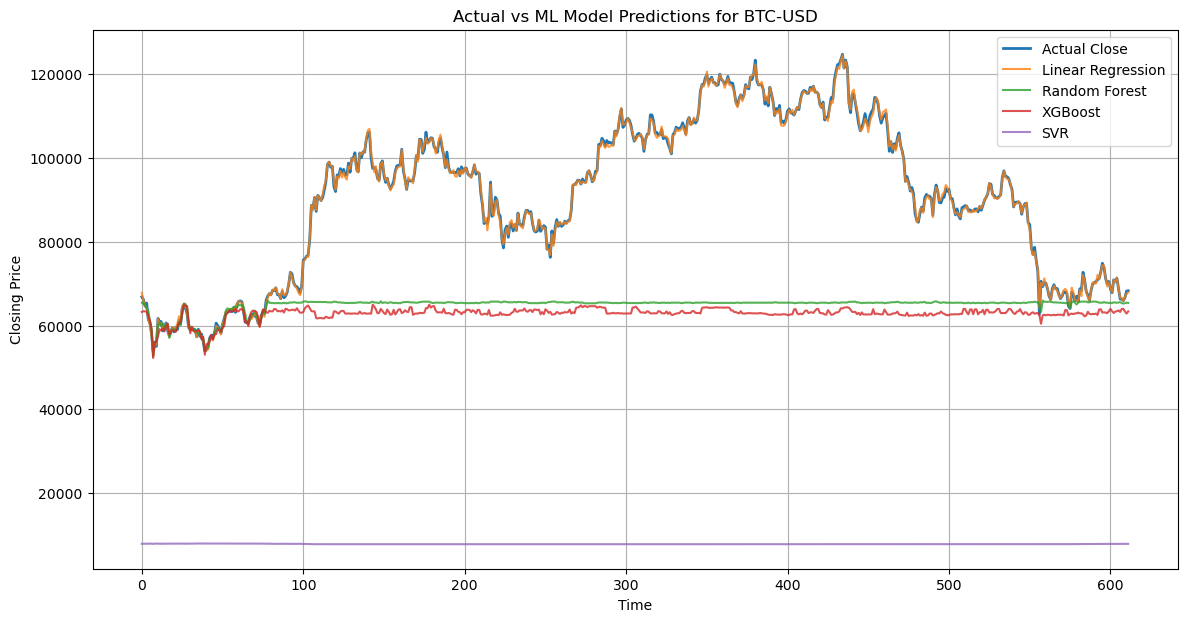

In [ ]:
coin_to_plot = "BTC-USD"

y_test_ml = all_predictions[coin_to_plot]["y_test_ml"]
preds = all_predictions[coin_to_plot]["predictions"]

plt.figure(figsize=(14, 7))
plt.plot(y_test_ml, label="Actual Close", linewidth=2)

for model_name in ["Linear Regression", "Random Forest", "XGBoost", "SVR"]:
    if preds[model_name] is not None:
        plt.plot(preds[model_name], label=model_name, alpha=0.8)

plt.title(f"Actual vs ML Model Predictions for {coin_to_plot}")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

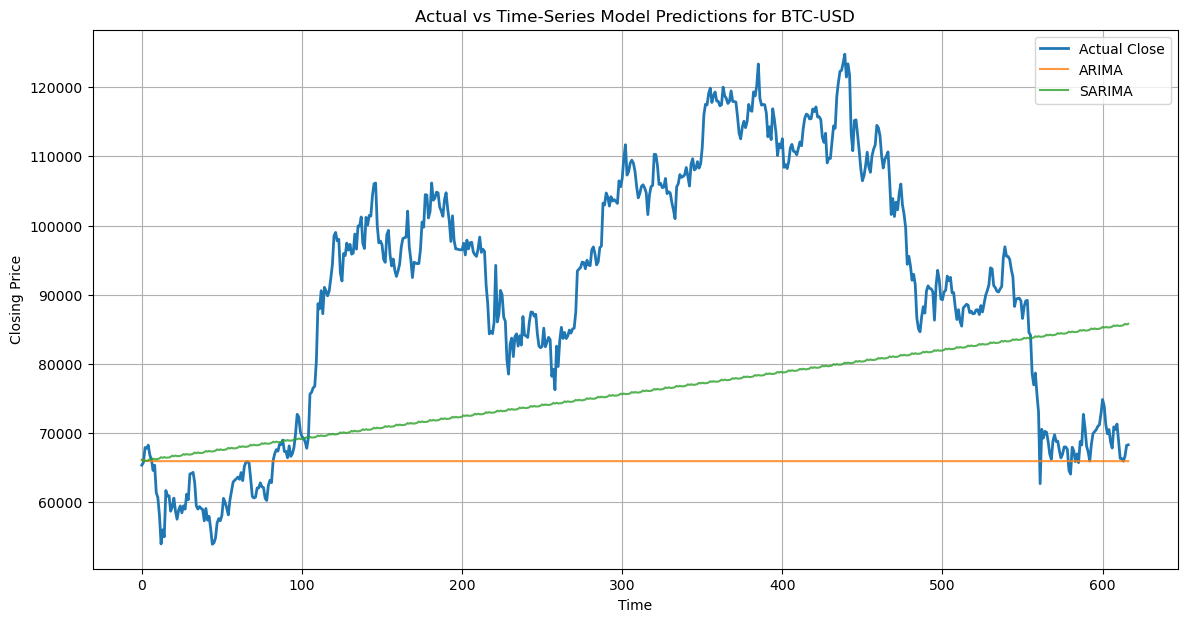

In [ ]:
coin_to_plot = "BTC-USD"

y_test_ts = all_predictions[coin_to_plot]["y_test_ts"]
preds = all_predictions[coin_to_plot]["predictions"]

plt.figure(figsize=(14, 7))
plt.plot(y_test_ts, label="Actual Close", linewidth=2)

for model_name in ["ARIMA", "SARIMA"]:
    if preds[model_name] is not None:
        plt.plot(preds[model_name], label=model_name, alpha=0.8)

plt.title(f"Actual vs Time-Series Model Predictions for {coin_to_plot}")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

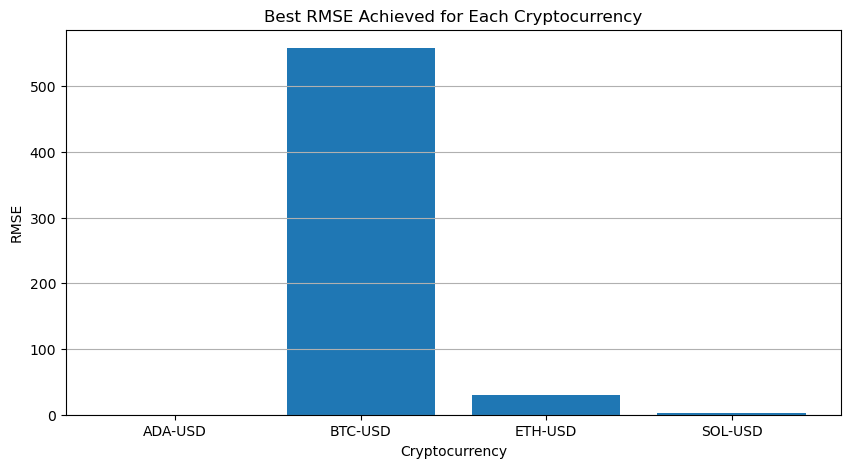

,Coin,Model,RMSE
12,ADA-USD,Linear Regression,0.010584
0,BTC-USD,Linear Regression,558.250528
6,ETH-USD,Linear Regression,30.588479
18,SOL-USD,Linear Regression,1.871680


In [ ]:
plt.figure(figsize=(10, 5))
best_rmse_df = results_df.loc[results_df.groupby("Coin")["RMSE"].idxmin()][["Coin", "Model", "RMSE"]]
plt.bar(best_rmse_df["Coin"], best_rmse_df["RMSE"])
plt.title("Best RMSE Achieved for Each Cryptocurrency")
plt.xlabel("Cryptocurrency")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()

best_rmse_df